In [3]:
import pandas as pd
import numpy as np

In [14]:
import os

print(os.getcwd())
print(os.listdir())

print(os.path.exists("./data/raw/NFLX.csv"))

/Users/amit/Desktop/InvestIQ/ml
['agent.ipynb', '.ipynb_checkpoints', 'data']
True


In [35]:
df = pd.read_csv("./data/raw/NFLX.csv")
dff = pd.read_csv("./data/raw/nifty50_historical_data.csv")
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287310 entries, 0 to 287309
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            287310 non-null  object 
 1   Ticker          287310 non-null  object 
 2   Company_Name    287310 non-null  object 
 3   Sector          287310 non-null  object 
 4   Open            287310 non-null  float64
 5   High            287310 non-null  float64
 6   Low             287310 non-null  float64
 7   Close           287310 non-null  float64
 8   Volume          287310 non-null  int64  
 9   Dividend        287310 non-null  float64
 10  Stock_Split     98 non-null      float64
 11  Daily_Return    287261 non-null  float64
 12  Volatility_20D  286330 non-null  float64
 13  MA_50           284909 non-null  float64
 14  MA_200          277559 non-null  float64
 15  Market_Cap      287310 non-null  int64  
 16  PE_Ratio        281453 non-null  float64
 17  Forward_PE

In [38]:
dff.describe()
dff.isnull().sum()
dff.duplicated().sum()

np.int64(0)

In [41]:
dff["Date"] = pd.to_datetime(dff["Date"])
dff["Date"].dtype

dff.isnull().sum()[dff.isnull().sum() > 0]

dff["Date"].min(), dff["Date"].max()

dff["Ticker"].nunique()

dff["Sector"].value_counts()

dff.groupby("Ticker")["Date"].agg(["min", "max", "count"]).head(10)

,min,max,count
Ticker,,,
ADANIENT.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5858
ADANIPORTS.NS,2007-11-27 00:00:00+05:30,2026-01-30 00:00:00+05:30,4482
APOLLOHOSP.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856
ASIANPAINT.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856
AXISBANK.NS,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6767
BAJAJ-AUTO.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5859
BAJAJFINSV.NS,2002-08-12 00:00:00+05:30,2026-01-30 00:00:00+05:30,5825
BAJFINANCE.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856
BHARTIARTL.NS,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856


In [53]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


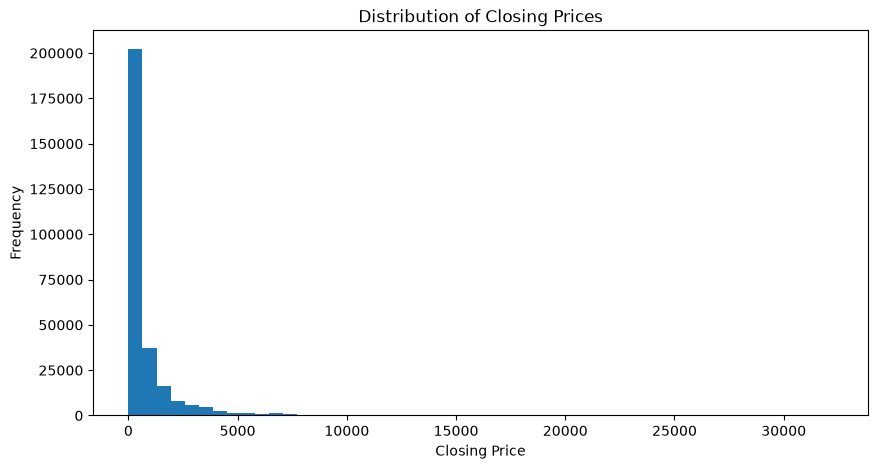

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(dff["Close"].dropna(), bins=50)
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Distribution of Closing Prices")
plt.show()

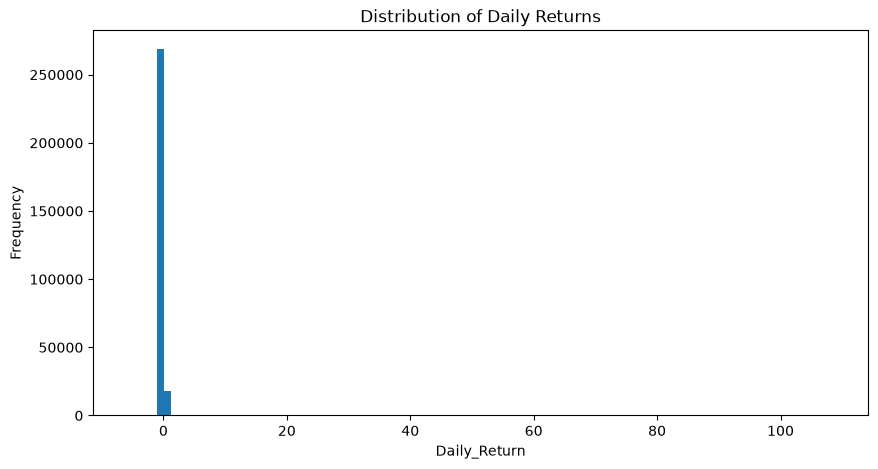

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(dff["Daily_Return"].dropna(), bins=100)
plt.xlabel("Daily_Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")
plt.show()

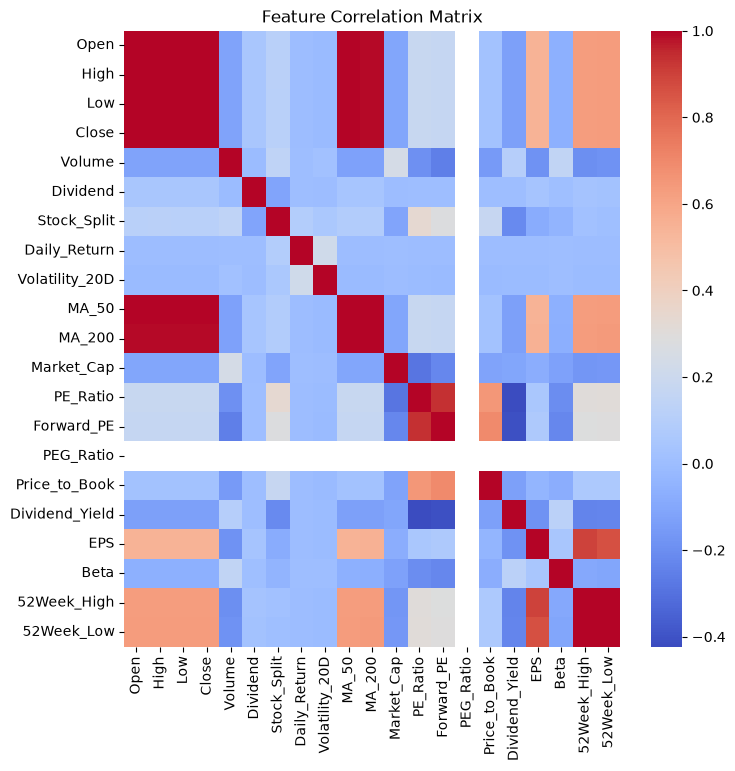

In [60]:
import seaborn as sns

numeric_cols = dff.select_dtypes(include="number")

plt.figure(figsize=(8, 8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

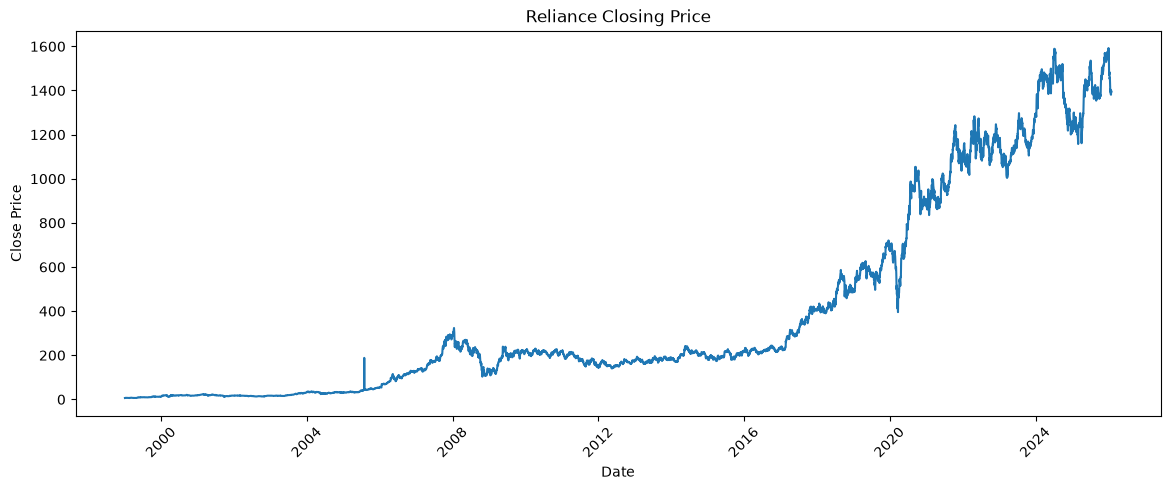

In [55]:
company = dff[dff["Ticker"] == "RELIANCE.NS"].sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(company["Date"], company["Close"])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Reliance Closing Price")
plt.xticks(rotation=45)
plt.show()

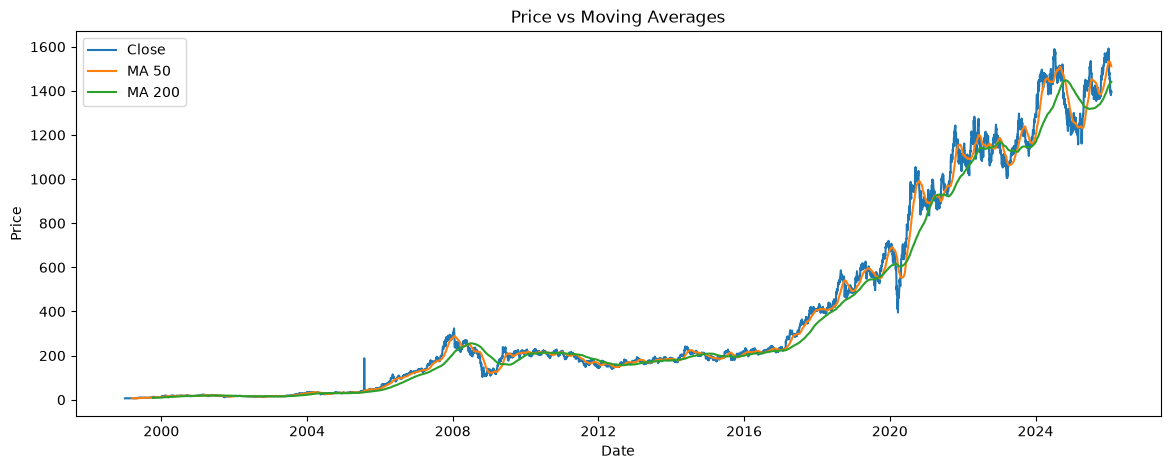

In [56]:
plt.figure(figsize=(14, 5))

plt.plot(company["Date"], company["Close"], label="Close")
plt.plot(company["Date"], company["MA_50"], label="MA 50")
plt.plot(company["Date"], company["MA_200"], label="MA 200")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Price vs Moving Averages")
plt.legend()
plt.show()

In [63]:
dff = dff.sort_values(["Ticker", "Date"]).reset_index(drop=True)

dff["Future_Close_21D"] = (
    dff.groupby("Ticker")["Close"]
      .shift(-21)
)


In [65]:
dff["Future_Return_21D"] = (
    dff["Future_Close_21D"] / dff["Close"] - 1
) * 100


In [66]:
dff[[
    "Ticker",
    "Date",
    "Close",
    "Future_Close_21D",
    "Future_Return_21D"
]].head(30)

,Ticker,Date,Close,Future_Close_21D,Future_Return_21D
0,ADANIENT.NS,2002-07-01 00:00:00+05:30,-0.012173,-0.010989,-9.730053
1,ADANIENT.NS,2002-07-02 00:00:00+05:30,-0.012269,-0.010886,-11.272312
2,ADANIENT.NS,2002-07-03 00:00:00+05:30,-0.012269,-0.011016,-10.212053
3,ADANIENT.NS,2002-07-04 00:00:00+05:30,-0.012337,-0.010906,-11.598291
4,ADANIENT.NS,2002-07-05 00:00:00+05:30,-0.012310,-0.010886,-11.568393
5,ADANIENT.NS,2002-07-08 00:00:00+05:30,-0.012851,-0.010735,-16.462450
6,ADANIENT.NS,2002-07-09 00:00:00+05:30,-0.012515,-0.010934,-12.636766
7,ADANIENT.NS,2002-07-10 00:00:00+05:30,-0.012502,-0.010769,-13.855434
8,ADANIENT.NS,2002-07-11 00:00:00+05:30,-0.012296,-0.010852,-11.748395
9,ADANIENT.NS,2002-07-12 00:00:00+05:30,-0.012392,-0.010900,-12.044187
